<div align="center">

# `BayeSym𝕏`: End-to-End Examples

</div>

## A toy example

- $y = 1.25 + 2.5 \exp(x_0^3)  - 0.8 x_1^2 \sin(x_0) + \varepsilon$, where $\varepsilon$ is Gaussian noise with standard deviation $\sigma = 0.25$.

- $(n, p) = (2000, 2)$.

In [1]:
# import everything from BayeSymX

from BayeSymX import *

### Simulated data generation and train-test split

In [4]:
rng = np.random.default_rng(2026)

# Generate 2000 observations with two features.
X = rng.uniform(-2.0, 2.0, size=(2000, 2))

# Ground-truth relationship:
y = (
    1.25
    + 2.5 * np.exp(X[:, 0] ** 3)
    - 0.8 * (X[:, 1] ** 2) * np.sin(X[:, 0])
    + rng.normal(0.0, 0.25, size=X.shape[0])
)

# Reproducible 90%/10% train-test split.
indices = rng.permutation(X.shape[0])
train_indices = indices[:1800]
test_indices = indices[1800:]

X_train = X[train_indices]
y_train = y[train_indices]
X_test = X[test_indices]
y_test = y[test_indices]

### Run `BayeSym𝕏`


╭──────────────────────────────────────────────────────────────────────╮
│                           Running BayeSym𝕏                           │
├──────────────────────────────────────────────────────────────────────┤
│  Parallel MCMC chains : 5                                            │
│  MCMC iterations      : 2,000 per chain                              │
│  Trees per forest     : 3                                            │
│  Operator set         : [add, neg, mul, inv, sin, cos, exp, sq, cu]  │
╰──────────────────────────────────────────────────────────────────────╯



Chain 1 | seed=101:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 2 | seed=202:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 3 | seed=303:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 4 | seed=404:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 5 | seed=505:   0%|          | 0/2000 [00:00<?, ?it/s]

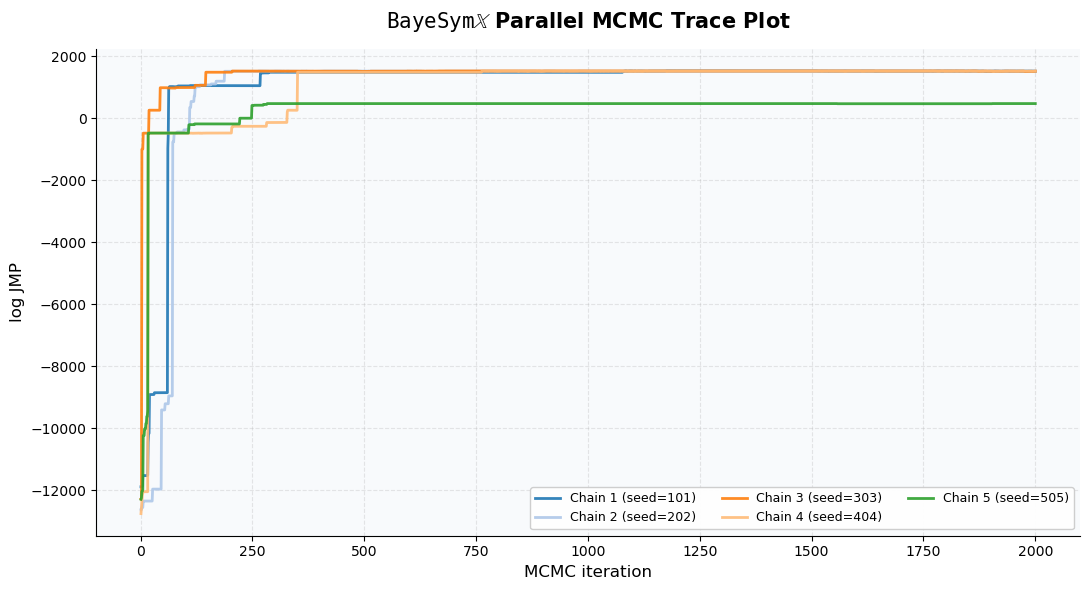


╔════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                              BayeSym𝕏                                              ║
║                                         Summary of Results                                         ║
╚════════════════════════════════════════════════════════════════════════════════════════════════════╝

Run overview
  • Ranked models     : 10 returned (10 requested)
  • Ranking statistic : log_JMP
  • Reduction method  : BIC and SymPy
  ✓ Evaluation        : training and held-out test metrics

 Raw symbolic models ───────────────────────────────────────────────────────────────────────────────
  
 Rank                                                               Raw expression  Train RMSE  Train MAE  Train R^2  Test RMSE  Test MAE  Test R^2  JMP
    1 1.26 + 1.25*(exp((x0)^3)) - 0.7965*((sin(x0) * (x1)^2)) + 1.25*(exp((x0)^3))      0.2487     0.1982          1      0.264    0.21

In [ ]:
result_json = run_bayesymx(
    X_train = X_train,                                          # train X
    y_train = y_train,                                          # train y
    K = 3,                                                      # symbolic forest size
    maxdepth = 3,                                               # max. depth of symbolic trees
    seeds = [101, 202, 303, 404, 505],                          # 5 parallel MCMC chains
    prior_params=None,                                          # default prior parameters
    add_intercept=True,                                         # add intercept term
    wts_init=None,                                              # default weights initialization
    wts_prop=None,                                              # default weights proposal distribution
    opset=[add, neg, mul, inv, sin, cos, exp, sq, cu],          # 9 operators
    ftset=["x0", "x1"],                                         # 2 features
    move_weights=[1, 1, 1, 1, 1, 1, 1],                         # all moves with equal probability
    maxiter=2000,                                               # MCMC iterations per chain
    burnin=0,                                                   # default; no burn-in        
    thin=1,                                                     # default; no thinning
    n_jobs=5,                                                   # number of parallel jobs (chains)    
    show_progress=True,                                         # show progress bar
    report_every=10,                                            # report progress every 10 iterations
    r=10,                                                       # no. of top-ranked JMP symbolic models
    X_test=X_test,                                              # test X
    y_test=y_test,                                              # test y
    force_intercept=False,                                      # force intercept term in final symbolic models    
    blr_prior=None,                                             # default prior for re-estimation of coefficients    
    prior_variance=10.0,                                        # default prior variance for re-estimation of coefficients
    rcond=None,                                                 # default cutoff for least-squares and pseudoinverse computations
    significant_digits=4,                                       # significant digits for rounding coefficients in final expressions    
    print_results=True,                                         # print results to console    
    show_trace_plot=True,                                       # show trace plot of log(JMP) for all chains
    save_trace_plot=False,                                      # save trace plot of log(JMP) for all chains    
    trace_plot_path=None,                                       # path to save trace plot of log(JMP) for all chains    
    trace_plot_dpi=300,                                         # dpi for trace plot of log(JMP) for all chains    
)

## Learning Feynman equation

I_50_26 (HOQN): $x = x_1[\cos(\omega t) + \alpha \cos^{2}(\omega t)]$ represents the harmonic oscillation with a quadratic nonlinear correction. The features ($p=4$) denote:

- $x_1$: amplitide/initial displacement scale; 
- $\omega$: angular frequency; 
- $t$: time; and
- $\alpha$: nonlinear correction parameter. 

The target is $x$: position/displacement.

![Feynman I_50_26](assets/feynman_hoqn_physical_tree.png)

### Loading Feynman I_50_26 data

Load the data from `feynman_data/feynman_I_50_26.tsv`. The noiseless original target has been used below.

In [8]:
# subsample 2000 observations from the Feynman dataset and split into 90% train and 10% test.

random_seed = 2026
sample_size = 2000     
test_fraction = 0.10

data_path = Path("feynman_data/feynman_I_50_26.tsv")

data = pd.read_csv(data_path, sep="\t")

target_column = "target"

if target_column not in data.columns:
    raise ValueError(
        f"The dataset must contain a "
        f"{target_column!r} column."
    )

feature_columns = [
    column
    for column in data.columns
    if column != target_column
]

if not feature_columns:
    raise ValueError(
        "No feature columns were found."
    )

print(
    f"Loaded {data_path.name}: "
    f"{len(data):,} observations, "
    f"{len(feature_columns)} features."
)

print("Features: " + ", ".join(feature_columns))


# ---------------------------------------------------------
# Optional reproducible subsampling
# ---------------------------------------------------------

rng = np.random.default_rng(random_seed)

if sample_size is not None:
    if not isinstance(sample_size, int) or sample_size <= 0:
        raise ValueError(
            "sample_size must be a positive integer "
            "or None."
        )

    if sample_size > len(data):
        raise ValueError(
            f"sample_size={sample_size:,} exceeds the "
            f"{len(data):,} available observations."
        )

    sampled_indices = rng.choice(
        len(data),
        size=sample_size,
        replace=False,
    )

    data = (
        data.iloc[sampled_indices]
        .reset_index(drop=True)
    )

    print(
        f"Using a reproducible sample of "
        f"{len(data):,} observations."
    )


# ---------------------------------------------------------
# Construct X and y
# ---------------------------------------------------------

X = data[feature_columns].to_numpy(dtype=float)

y = data[target_column].to_numpy(dtype=float)

if not np.all(np.isfinite(X)):
    raise ValueError("The feature matrix contains non-finite values.")

if not np.all(np.isfinite(y)):
    raise ValueError("The target vector contains non-finite values.")


# ---------------------------------------------------------
# Reproducible train-test split
# ---------------------------------------------------------

if not 0.0 < test_fraction < 1.0:
    raise ValueError(
        "test_fraction must be between 0 and 1."
    )

indices = rng.permutation(X.shape[0])

n_test = max(
    1,
    int(round(test_fraction * X.shape[0])),
)

test_indices = indices[:n_test]
train_indices = indices[n_test:]

X_train = X[train_indices]
y_train = y[train_indices]

X_test = X[test_indices]
y_test = y[test_indices]

print(
    f"Training observations: {len(y_train):,}"
)

print(
    f"Test observations:     {len(y_test):,}"
)

Loaded feynman_I_50_26.tsv: 100,000 observations, 4 features.
Features: x1, omega, t, alpha
Using a reproducible sample of 2,000 observations.
Training observations: 1,800
Test observations:     200


In [ ]:
# import everything from BayeSymX

from BayeSymX import *

### Run `BayeSym𝕏`


╭──────────────────────────────────────────────────────────────────────╮
│                           Running BayeSym𝕏                           │
├──────────────────────────────────────────────────────────────────────┤
│  Parallel MCMC chains : 10                                           │
│  MCMC iterations      : 2,000 per chain                              │
│  Trees per forest     : 3                                            │
│  Operator set         : [add, mul, inv, neg, sin, cos, exp, cu, sq]  │
╰──────────────────────────────────────────────────────────────────────╯



Chain 1 | seed=101:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 2 | seed=202:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 3 | seed=303:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 4 | seed=404:   0%|          | 0/2000 [00:00<?, ?it/s]

...

Chain 6 | seed=606:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 7 | seed=707:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 8 | seed=808:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 9 | seed=909:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 10 | seed=1010:   0%|          | 0/2000 [00:00<?, ?it/s]

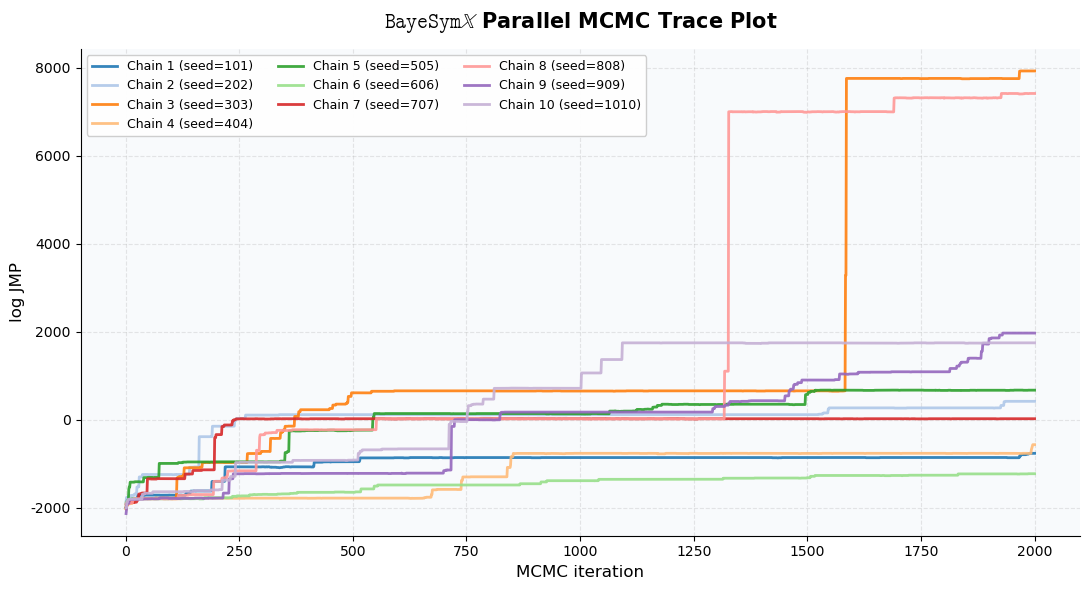


╔════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                              BayeSym𝕏                                              ║
║                                         Summary of Results                                         ║
╚════════════════════════════════════════════════════════════════════════════════════════════════════╝

Run overview
  • Ranked models     : 10 returned (10 requested)
  • Ranking statistic : log_JMP
  • Reduction method  : BIC and SymPy
  ✓ Evaluation        : training and held-out test metrics

 Raw symbolic models ───────────────────────────────────────────────────────────────────────────────
  
 Rank                                                                                                                                 Raw expression  Train RMSE  Train MAE  Train R^2  Test RMSE  Test MAE  Test R^2      JMP
    1 7.74e-06 + 0.5*((cos((t * omega)) * (x1 + x1))) + 0.25*((co

In [9]:
result_json = run_bayesymx(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,

    K=3,
    maxdepth=5,

    seeds=[
        101,
        202,
        303,
        404,
        505,
        606,
        707,
        808,
        909,
        1010
    ],

    maxiter=2000,
    burnin=0,
    thin=1,

    # Use the original Feynman variable names in the
    # resulting symbolic expressions.
    ftset=feature_columns,

    significant_digits=3,
    print_results=True,
    
    # Trace plots
    show_trace_plot=True,
    save_trace_plot=False,
    report_every=20,
    n_jobs=10,
    opset=[add, mul, inv, neg, sin, cos, exp, cu, sq]
)

## Descriptor discovery for oxide perovskites catalysts

The dataset is based on the oxide perovskite catalyst OER study of Weng et al. (2020) [https://doi.org/10.1038/s41467-020-17263-9], where the response variable is the OER potential $V_{\mathrm{RHE}}$ measured for perovskite catalysts of the form $ABO_{3}$. The original study synthesized $18$ known perovskites, prepared $4$ samples per material, repeated the OER measurement $3$ times per sample, and recorded $V_{\mathrm{RHE}}$ at $5$ current densities, yielding $n = 18\times 4\times 3\times 5 = 1080$ observations.

The features were chemically motivated descriptors including $R_A$ [weighted averaged ionic radii of cation A; note that for oxide pervskites $(A_x^1 A_{1-x}^2)(B_y^1 B_{1-y}^2)O_3$, the weighted averaged ionic radii of cation $A$ is $R_A = x\cdot R_{A^1} + (1-x)\cdot R_{A^{2}}$], $Q_A$ [weighted averaged charged state of cation A], $N_d$ [weighted averaged number of $d$ electrons of cation A], $\chi_A$ [weighted averaged atomic radii of A], $\chi_B$ [weighted averaged atomic radii of B], the tolerance factor $t = \tfrac{R_A + R_O}{\sqrt{2}(R_B + R_O)}$ [$R_B$ is the weighted averaged ionic radii of cation $B$ and $R_O$ is the ionic radii of anion $O^{2-}$] and the octahedral factor $\mu = \frac{R_B}{R_O}$. We also include the $5$ current densities, i.e., $50\mu \mathrm{A}/\mathrm{cm}^2$, $5 \mathrm{mA}/\mathrm{cm}^{2}$, $10 \mathrm{mA}/\mathrm{cm}^{2}$, $15 \mathrm{mA}/\mathrm{cm}^{2}$, and $20 \mathrm{mA}/\mathrm{cm}^{2}$, in the feature set to model $V_{\mathrm{RHE}}$, i.e., $(n, p) = (1080, 8)$.

The figure below illustrates the landscape of all $V_{\mathrm{RHE}}$ data produced by experiments.

<p align="center">
<img src="assets/VRHE_landscape_3D.png" alt="VRHE landscape" width="500">
</p>


### Ablation study as a practical diagnostic to choose $K$

We consider the $K$ grid values `K_GRID = [6, 7, 8, 10, 12]`. For a particular 90/10 train-test split of the oxide perovskite catalyst dataset, the test RMSE and MAE (corresponding to the top-ranked JMP descriptor expression) along with the parallel-chain compute runtime of `BayeSym𝕏` are recorded across the $K$ values. This serves as a practical guideline in choosing the nominal symbolic forest size $K$.

#### 90/10 train-test split of the dataset

In [13]:
from BayeSymX import *

# ---------------------------------------------------------
# Data configuration
# ---------------------------------------------------------

data_path = Path(
    "perovskites_data/processed_data.csv"
)

target_column = "VRHE"

feature_columns = [
    "current_Density",
    "RA",
    "RB",
    "t",
    "mu",
    "XA",
    "XB",
    "QA",
    "Nd",
]

random_seed = 2026
train_fraction = 0.90


# ---------------------------------------------------------
# Load the data
# ---------------------------------------------------------

data = pd.read_csv(data_path)

data = data.rename(
    columns={
        "current_density": "current_Density",
    }
)

X = data[
    feature_columns
].to_numpy(dtype=float)

y = data[
    target_column
].to_numpy(dtype=float)


# ---------------------------------------------------------
# Fixed random 90%/10% train-test split
#
# This exact split is reused for every K.
# ---------------------------------------------------------

rng = np.random.default_rng(
    random_seed
)

indices = rng.permutation(
    len(data)
)

n_train = int(
    train_fraction * len(data)
)

train_indices = indices[:n_train]
test_indices = indices[n_train:]

X_train = X[train_indices]
y_train = y[train_indices]

X_test = X[test_indices]
y_test = y[test_indices]

print(f"Total observations:    {len(data):,}")
print(f"Training observations: {len(y_train):,}")
print(f"Test observations:     {len(y_test):,}")

Total observations:    1,080
Training observations: 972
Test observations:     108


#### Ablation configuration

In [14]:
# ---------------------------------------------------------
# K ablation grid
# ---------------------------------------------------------

K_GRID = [
    6,
    7,
    8,
    10,
    12,
]


# ---------------------------------------------------------
# Fixed BayeSymX settings
# ---------------------------------------------------------

MAXDEPTH = 6
MAXITER = 2_000
TOP_R = 10

CHAIN_SEEDS = [
    123,
    124,
    125,
    126,
    127,
]

OPERATOR_SET = [
    add,
    mul,
    neg,
    inv,
    sqrt_op,
]

MOVE_WEIGHTS = {
    "grow": 1.0,
    "prune": 1.0,
    "change_feature": 1.0,
    "change_operator": 1.0,
    "subtree_replace": 1.0,
    "delete_node": 1.0,
    "insert_node": 1.0,
}

#### Run the $K$ ablation study for `BayeSym𝕏`

In [17]:
ablation_rows = []
ablation_results_by_k = {}

number_of_operators = len(
    OPERATOR_SET
)

number_of_features = len(
    feature_columns
)


for K in K_GRID:
    print()
    print("=" * 72)
    print(f"Running BayeSym𝕏 with K={K}")
    print("=" * 72)

    # K tree coefficients plus one intercept.
    number_of_coefficients = K + 1

    prior_params = (
        # Operator Dirichlet concentrations
        np.ones(
            number_of_operators,
            dtype=float,
        ),

        # Feature Dirichlet concentrations
        np.ones(
            number_of_features,
            dtype=float,
        ),

        # Tree split-probability parameter
        0.95,

        # Tree depth penalty
        2.00,

        # Regression coefficient prior mean
        np.zeros(
            number_of_coefficients,
            dtype=float,
        ),

        # Regression coefficient prior covariance
        10.0 * np.eye(
            number_of_coefficients,
            dtype=float,
        ),

        # Inverse-gamma parameters
        0.05,
        0.05,
    )

    wts_init = [
        np.ones(
            number_of_operators,
            dtype=float,
        ),
        np.ones(
            number_of_features,
            dtype=float,
        ),
    ]

    wts_prop = [
        np.ones(
            number_of_operators,
            dtype=float,
        ),
        np.ones(
            number_of_features,
            dtype=float,
        ),
    ]

    result_json = run_bayesymx(
        # Fixed training and test data
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,

        # Forest configuration
        K=K,
        maxdepth=MAXDEPTH,
        seeds=CHAIN_SEEDS,

        # Priors
        prior_params=prior_params,
        add_intercept=True,

        # Initial and proposal weights
        wts_init=wts_init,
        wts_prop=wts_prop,

        # Search space
        opset=OPERATOR_SET,
        ftset=feature_columns,

        # Tree moves
        move_weights=MOVE_WEIGHTS,

        # MCMC settings
        maxiter=MAXITER,
        burnin=0,
        thin=1,
        n_jobs=len(CHAIN_SEEDS),
        show_progress=False,
        report_every=20,

        # Ranked forests
        r=TOP_R,

        # BIC reduction
        force_intercept=False,
        prior_variance=10.0,

        # Output
        significant_digits=6,
        print_results=False,

        # Disable individual trace plots during ablation
        show_trace_plot=False,
        save_trace_plot=False,
    )

    results = json.loads(
        result_json
    )

    ablation_results_by_k[K] = results

    # The first entry is the top log-JMP-ranked forest.
    top_ranked_model = results[
        "models"
    ][0]

    raw_model = top_ranked_model[
        "raw_model"
    ]

    final_model = top_ranked_model[
        "final_model"
    ]

    raw_test_metrics = raw_model[
        "test_metrics"
    ]

    final_test_metrics = final_model[
        "test_metrics"
    ]

    ablation_rows.append({
        "K": K,
        "log_JMP": raw_model["log_JMP"],
        "raw_expression": raw_model[
            "expression"
        ],
        "final_expression": final_model[
            "expression"
        ],
        "raw_test_RMSE": raw_test_metrics[
            "RMSE"
        ],
        "final_test_RMSE": final_test_metrics[
            "RMSE"
        ],
        "raw_test_MAE": raw_test_metrics[
            "MAE"
        ],
        "final_test_MAE": final_test_metrics[
            "MAE"
        ],
        "parallel_runtime_seconds": results[
            "parallel_chains_runtime_seconds"
        ],
        "source_chain_seed": top_ranked_model[
            "source"
        ]["chain_seed"],
        "source_iteration": top_ranked_model[
            "source"
        ]["iteration"],
    })

    print(
        f"K={K}: "
        f"raw test RMSE={raw_test_metrics['RMSE']:.6g}, "
        f"final test RMSE={final_test_metrics['RMSE']:.6g}, "
        f"runtime={results['parallel_chains_runtime_seconds']:.2f} s"
    )


ablation_table = pd.DataFrame(
    ablation_rows
).sort_values(
    "K"
).reset_index(
    drop=True
)

pd.set_option(
    "display.max_colwidth",
    100,
)

display(ablation_table)


Running BayeSym𝕏 with K=6
K=6: raw test RMSE=0.0863514, final test RMSE=0.0862059, runtime=46.37 s

Running BayeSym𝕏 with K=7
K=7: raw test RMSE=0.0857238, final test RMSE=0.0858361, runtime=56.21 s

Running BayeSym𝕏 with K=8
K=8: raw test RMSE=0.0861459, final test RMSE=0.0860327, runtime=69.21 s

Running BayeSym𝕏 with K=10
K=10: raw test RMSE=0.0833682, final test RMSE=0.0837535, runtime=84.66 s

Running BayeSym𝕏 with K=12
K=12: raw test RMSE=0.0846055, final test RMSE=0.0844784, runtime=112.75 s


,K,log_JMP,raw_expression,final_expression,raw_test_RMSE,final_test_RMSE,raw_test_MAE,final_test_MAE,parallel_runtime_seconds,source_chain_seed,source_iteration
0,6,1670.727076,0.737806 + 0.219244*(((1/(XB)) * current_Density)) - 0.290623*((-RB)) + 0.592908*((1/(t))) - 0.2...,0.859672*(0.031522*Nd*XB*current_Density*t - 0.129812*XB*current_Density*t*Abs(Nd)**0.5 + 1.0*XB...,0.086351,0.086206,0.059668,0.059604,46.365378,123,820
1,7,1655.275308,0.42618 + 0.291023*(((1/(XB)) * current_Density)) - 0.380016*((-XA)) + 0.40597*(sqrt(abs(XA))) -...,1.07427*(0.00475908*Nd*XB*current_Density - 0.0355997*XA*XB*current_Density + 0.496809*XA*XB - 0...,0.085724,0.085836,0.059989,0.059996,56.209531,124,582
2,8,1641.146295,0.484962 + 0.0136505*((current_Density * Nd)) + 0.445553*((1/(t))) + 0.445553*((1/(t))) + 0.2646...,0.959899*(0.0149484*Nd**2*current_Density*t - 0.0716644*Nd*XB*current_Density*t + 0.726721*Nd*t ...,0.086146,0.086033,0.058599,0.058582,69.209343,127,1592
3,10,1607.397490,0.360838 - 0.112702*(sqrt(abs((QA * current_Density)))) + 0.485804*(((1/(XB)) * current_Density)...,1.9229*(0.00269433*Nd**2*XB*current_Density + 0.205407*Nd*XB**2*Abs(current_Density)**0.5 - 0.15...,0.083368,0.083754,0.057021,0.057648,84.663174,125,321
4,12,1577.738564,0.262302 + 0.397544*((1/(Nd))) + 0.107833*((1/(current_Density))) + 0.397544*((1/(Nd))) + 0.2531...,0.925135*(0.00621517*Nd**2*RB*XB*current_Density**2*t + 0.535218*Nd*RB*XB**2*current_Density*t -...,0.084606,0.084478,0.057860,0.057610,112.748693,125,616


#### Plot the ablation results: test RMSE, test MAE, and parallel-chain runtime 

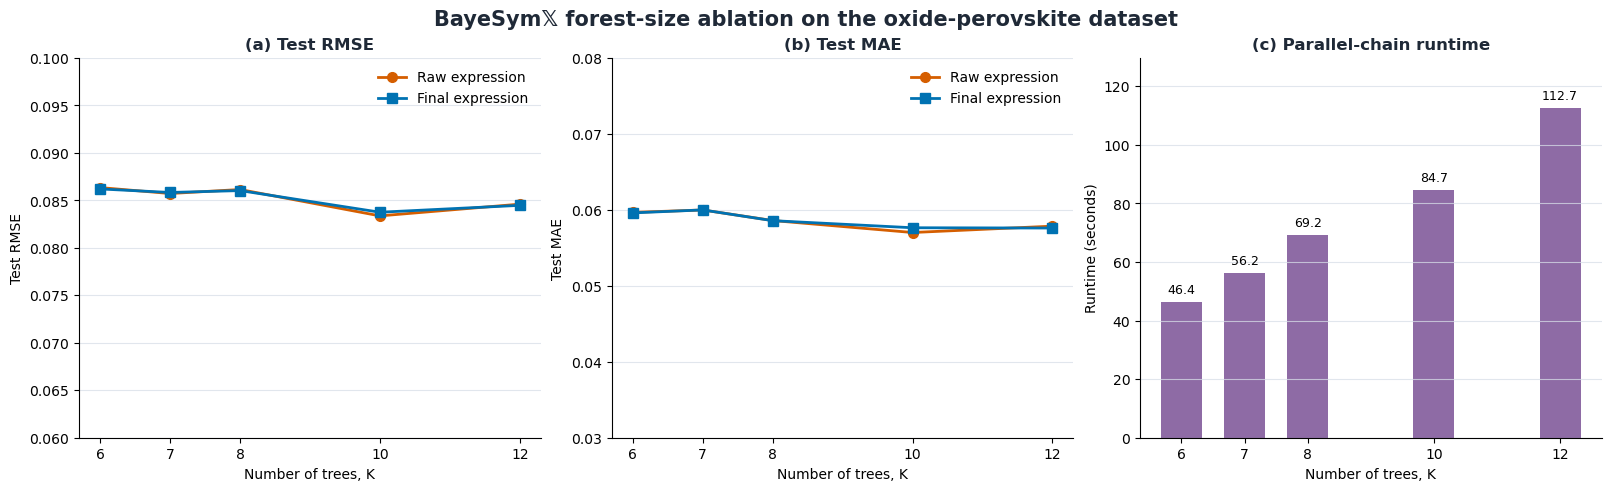

In [25]:
plot_data = ablation_table.sort_values(
    "K"
)

k_values = plot_data[
    "K"
].to_numpy()

raw_rmse = plot_data[
    "raw_test_RMSE"
].to_numpy()

final_rmse = plot_data[
    "final_test_RMSE"
].to_numpy()

raw_mae = plot_data[
    "raw_test_MAE"
].to_numpy()

final_mae = plot_data[
    "final_test_MAE"
].to_numpy()

runtime = plot_data[
    "parallel_runtime_seconds"
].to_numpy()


# ---------------------------------------------------------
# Plot style
# ---------------------------------------------------------

RAW_COLOR = "#D55E00"
FINAL_COLOR = "#0072B2"
RUNTIME_COLOR = "#7A5195"
GRID_COLOR = "#D7DEE7"
TEXT_COLOR = "#1F2937"


fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.8),
    constrained_layout=True,
)

ax_rmse, ax_mae, ax_runtime = axes


# ---------------------------------------------------------
# Test RMSE
# ---------------------------------------------------------

ax_rmse.plot(
    k_values,
    raw_rmse,
    color=RAW_COLOR,
    marker="o",
    markersize=7,
    linewidth=2.0,
    label="Raw expression",
)

ax_rmse.plot(
    k_values,
    final_rmse,
    color=FINAL_COLOR,
    marker="s",
    markersize=7,
    linewidth=2.0,
    label="Final expression",
)

ax_rmse.set_title(
    "(a) Test RMSE",
    color=TEXT_COLOR,
    fontweight="semibold",
)

ax_rmse.set_xlabel(
    "Number of trees, K"
)

ax_rmse.set_ylabel(
    "Test RMSE"
)

ax_rmse.set_xticks(
    k_values
)

ax_rmse.legend(
    frameon=False
)


# ---------------------------------------------------------
# Test MAE
# ---------------------------------------------------------

ax_mae.plot(
    k_values,
    raw_mae,
    color=RAW_COLOR,
    marker="o",
    markersize=7,
    linewidth=2.0,
    label="Raw expression",
)

ax_mae.plot(
    k_values,
    final_mae,
    color=FINAL_COLOR,
    marker="s",
    markersize=7,
    linewidth=2.0,
    label="Final expression",
)

ax_mae.set_title(
    "(b) Test MAE",
    color=TEXT_COLOR,
    fontweight="semibold",
)

ax_mae.set_xlabel(
    "Number of trees, K"
)

ax_mae.set_ylabel(
    "Test MAE"
)

ax_mae.set_xticks(
    k_values
)

ax_mae.legend(
    frameon=False
)


# ---------------------------------------------------------
# Parallel-chain runtime
# ---------------------------------------------------------

runtime_bars = ax_runtime.bar(
    k_values,
    runtime,
    color=RUNTIME_COLOR,
    width=0.65,
    alpha=0.85,
)

ax_runtime.set_title(
    "(c) Parallel-chain runtime",
    color=TEXT_COLOR,
    fontweight="semibold",
)

ax_runtime.set_xlabel(
    "Number of trees, K"
)

ax_runtime.set_ylabel(
    "Runtime (seconds)"
)

ax_runtime.set_xticks(
    k_values
)

ax_runtime.set_ylim(
    0,
    1.15 * runtime.max(),
)

ax_runtime.bar_label(
    runtime_bars,
    labels=[
        f"{value:.1f}"
        for value in runtime
    ],
    padding=4,
    fontsize=9,
)


# ---------------------------------------------------------
# Shared formatting
# ---------------------------------------------------------

for axis in axes:
    axis.grid(
        axis="y",
        color=GRID_COLOR,
        linewidth=0.8,
        alpha=0.75,
    )

    axis.spines[
        "top"
    ].set_visible(False)

    axis.spines[
        "right"
    ].set_visible(False)


fig.suptitle(
    "BayeSym𝕏 forest-size ablation on the oxide-perovskite dataset",
    fontsize=15,
    color=TEXT_COLOR,
    fontweight="semibold",
)

# Test RMSE axis limits
ax_rmse.set_ylim(
    0.06,   # lower limit
    0.10,  # upper limit
)

# Test MAE axis limits
ax_mae.set_ylim(
    0.03,   # lower limit
    0.08,  # upper limit
)

plt.show()

The preceding ablation results show that beyond $K=8$, there is no significant increase in the predictive accuracy. However, as expected the compute runtime increases linearly, hence to balance predictive performance with computational efficiency, we choose $K=8$ for the following `BayeSym𝕏` experiment.

### Run `BayeSym𝕏` on one 90/10 train-test split of the oxide perovskite catalyst dataset

Training observations: 972
Test observations:     108

╭────────────────────────────────────────────────────────────╮
│                      Running BayeSym𝕏                      │
├────────────────────────────────────────────────────────────┤
│  Parallel MCMC chains : 5                                  │
│  MCMC iterations      : 2,000 per chain                    │
│  Trees per forest     : 8                                  │
│  Operator set         : [add, mul, neg, inv, sqrt]         │
╰────────────────────────────────────────────────────────────╯



Chain 1 | seed=123:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 2 | seed=124:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 3 | seed=125:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 4 | seed=126:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 5 | seed=127:   0%|          | 0/2000 [00:00<?, ?it/s]

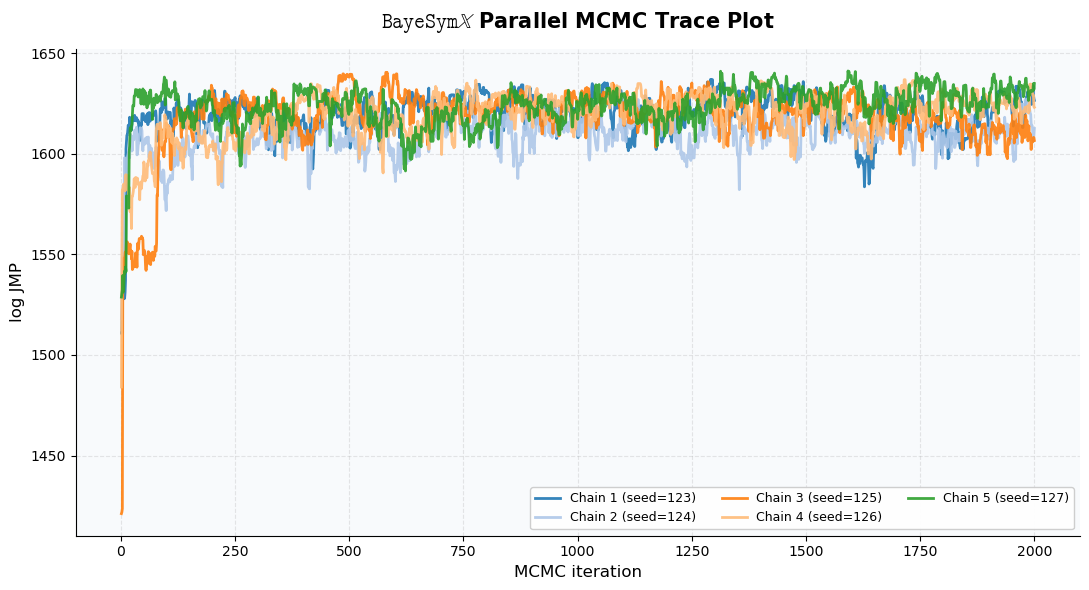


╔════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                              BayeSym𝕏                                              ║
║                                         Summary of Results                                         ║
╚════════════════════════════════════════════════════════════════════════════════════════════════════╝

Run overview
  • Ranked models     : 10 returned (10 requested)
  • Ranking statistic : log_JMP
  • Reduction method  : BIC and SymPy
  ✓ Evaluation        : training and held-out test metrics

 Raw symbolic models ───────────────────────────────────────────────────────────────────────────────
  
 Rank                                                                                                                                                                                                                                          Raw expression  Train RMSE  Train MAE  Train R^2 

In [12]:
# Import everything from BayeSymX.
from BayeSymX import *


# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

data_path = Path(
    "perovskites_data/processed_data.csv"
)

target_column = "VRHE"

feature_columns = [
    "current_Density",
    "RA",
    "RB",
    "t",
    "mu",
    "XA",
    "XB",
    "QA",
    "Nd",
]

random_seed = 2026
train_fraction = 0.90


# ---------------------------------------------------------
# Load the data
# ---------------------------------------------------------

data = pd.read_csv(data_path)

data = data.rename(
    columns={
        "current_density": "current_Density",
    }
)


# ---------------------------------------------------------
# Construct X and y
# ---------------------------------------------------------

X = data[
    feature_columns
].to_numpy(dtype=float)

y = data[
    target_column
].to_numpy(dtype=float)


# ---------------------------------------------------------
# Random 90% training and 10% test split
# ---------------------------------------------------------

rng = np.random.default_rng(
    random_seed
)

indices = rng.permutation(
    len(data)
)

n_train = int(
    train_fraction * len(data)
)

train_indices = indices[
    :n_train
]

test_indices = indices[
    n_train:
]

X_train = X[
    train_indices
]

y_train = y[
    train_indices
]

X_test = X[
    test_indices
]

y_test = y[
    test_indices
]

print(
    f"Training observations: {len(y_train):,}"
)

print(
    f"Test observations:     {len(y_test):,}"
)


# ---------------------------------------------------------
# BayeSymX settings
# ---------------------------------------------------------

K = 8
maxdepth = 6
top_r = 10
maxiter = 2_000

chain_seeds = [
    123,
    124,
    125,
    126,
    127,
]

operator_set = [
    add,
    mul,
    neg,
    inv,
    sqrt_op,
]

move_weights = {
    "grow": 1.0,
    "prune": 1.0,
    "change_feature": 1.0,
    "change_operator": 1.0,
    "subtree_replace": 1.0,
    "delete_node": 1.0,
    "insert_node": 1.0,
}


# ---------------------------------------------------------
# Prior parameters
# ---------------------------------------------------------

number_of_operators = len(
    operator_set
)

number_of_features = len(
    feature_columns
)

number_of_coefficients = K + 1

prior_params = (
    np.ones(
        number_of_operators,
        dtype=float,
    ),
    np.ones(
        number_of_features,
        dtype=float,
    ),
    0.95,
    2.00,
    np.zeros(
        number_of_coefficients,
        dtype=float,
    ),
    10.0 * np.eye(
        number_of_coefficients,
        dtype=float,
    ),
    0.05,
    0.05,
)


# ---------------------------------------------------------
# Initial and proposal weights
# ---------------------------------------------------------

wts_init = [
    np.ones(
        number_of_operators,
        dtype=float,
    ),
    np.ones(
        number_of_features,
        dtype=float,
    ),
]

wts_prop = [
    np.ones(
        number_of_operators,
        dtype=float,
    ),
    np.ones(
        number_of_features,
        dtype=float,
    ),
]


# ---------------------------------------------------------
# Run BayeSymX
# ---------------------------------------------------------

result_json = run_bayesymx(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,

    K=K,
    maxdepth=maxdepth,
    seeds=chain_seeds,

    prior_params=prior_params,
    add_intercept=True,

    wts_init=wts_init,
    wts_prop=wts_prop,

    opset=operator_set,
    ftset=feature_columns,

    move_weights=move_weights,

    maxiter=maxiter,
    burnin=0,
    thin=1,
    n_jobs=len(chain_seeds),
    show_progress=True,
    report_every=20,

    r=top_r,

    force_intercept=False,
    prior_variance=10.0,

    significant_digits=6,
    print_results=True,

    show_trace_plot=True,
    save_trace_plot=False,
)